# KAN — Kolmogorov-Arnold Network dla BTC/USDT

Notebook bazuje na tym samym eksperymencie co przygotowany wcześniej notebook MOMENT-1:

- wejście z `btc_usdt_1h.csv`,
- `log_return_close` jako sygnał wejściowy,
- target `bin_return_d2d_close`,
- chronologiczny split **70 / 15 / 15**,
- okno **240** poprzednich obserwacji,
- historyczny kontekst dla validation/test bez leakage,
- klasyfikacja binarna 0/1,
- classification report, ROC-AUC, confusion matrix i ten sam backtest.

Model MOMENT został zastąpiony siecią **Kolmogorova-Arnolda (KAN)**.

Implementacja KAN w tym notebooku jest samodzielna i oparta na PyTorch: każda krawędź warstwy uczy się funkcji 1D złożonej z funkcji bazowych RBF. Dzięki temu notebook nie zależy od zewnętrznego pakietu KAN i działa na współczesnym środowisku Google Colab.


## 1. Importy


In [1]:
import copy
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3
PyTorch: 2.11.0+cu130


## 2. Konfiguracja


In [2]:
LAGS_NUM = 240

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

EPOCHS_NUM = 100
BATCH_SIZE = 64
PATIENCE_NUM = 12

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_GRAD_NORM = 1.0

# Tak samo jak w oryginalnym notebooku LSTM.
SCALER_BOOLEAN = True

OUTPUT_VALUE = "bin_return_d2d_close"

# Architektura KAN:
# 240 lagów -> 64 neuronów KAN -> 16 neuronów KAN -> 2 logity
KAN_HIDDEN_DIMS = [64, 16]

# Liczba funkcji RBF na każdej krawędzi.
GRID_SIZE = 8

# Zakres siatki po standaryzacji.
GRID_RANGE = (-3.0, 3.0)

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    print(
        "Możesz włączyć GPU w Colabie: "
        "Runtime -> Change runtime type -> GPU."
    )


Device: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


## 3. Wczytanie CSV


In [4]:
CSV_PATH = "/content/btc_usdt_1h.csv"

# Google Drive — alternatywnie:
# from google.colab import drive
# drive.mount("/content/drive")
# CSV_PATH = "/content/drive/MyDrive/btc_usdt_1h.csv"

if not Path(CSV_PATH).exists():
    raise FileNotFoundError(
        f"Nie znaleziono {CSV_PATH}. "
        "Wgraj btc_usdt_1h.csv do Colaba albo zmień CSV_PATH."
    )

data = pd.read_csv(
    CSV_PATH,
    parse_dates=["Date"],
)

required_columns = {
    "Date", "Open", "High", "Low", "Close", "Volume"
}

missing_columns = required_columns.difference(data.columns)

if missing_columns:
    raise ValueError(
        f"Brakuje kolumn: {sorted(missing_columns)}"
    )

data = (
    data
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .set_index("Date")
)

print("Shape:", data.shape)
display(data.head())
display(data.tail())


Shape: (21097, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00+00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00+00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00+00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00+00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00+00:00,34716.78,34725.00,34653.84,34696.65,654.53035


,Open,High,Low,Close,Volume
Date,,,,,
2026-03-31 16:00:00+00:00,66736.79,68030.19,66729.28,67665.83,1334.03651
2026-03-31 17:00:00+00:00,67665.83,68589.49,67403.81,67526.75,2195.81331
2026-03-31 18:00:00+00:00,67526.76,67947.98,67526.30,67854.05,426.40012
2026-03-31 19:00:00+00:00,67854.04,68029.41,67716.35,67838.80,435.24470
2026-03-31 20:00:00+00:00,67838.79,68267.27,67831.70,68265.53,693.06575


## 4. Kontrola ciągłości


In [5]:
all_dates = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h",
)

missing = all_dates.difference(data.index)

print("Pierwszy timestamp:", data.index.min())
print("Ostatni timestamp:", data.index.max())
print("Brakujące timestampy:", len(missing))

if len(missing):
    display(pd.Series(missing[:50], name="missing_timestamp"))


Pierwszy timestamp: 2023-11-03 20:00:00+00:00
Ostatni timestamp: 2026-03-31 20:00:00+00:00
Brakujące timestampy: 0


## 5. Feature engineering i target


In [6]:
data["log_return_close"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

data["return_close"] = (
    data["Close"] / data["Close"].shift(1) - 1
)

data["bin_return_close"] = (
    data["log_return_close"] > 0
).astype(np.int64)

data["bin_return_d2d_close"] = (
    data["log_return_close"]
    > data["log_return_close"].shift(1)
).astype(np.int64)

data = data.dropna().copy()

display(
    data[
        [
            "Close",
            "log_return_close",
            "return_close",
            "bin_return_close",
            "bin_return_d2d_close",
        ]
    ].head()
)


,Close,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,
2023-11-03 21:00:00+00:00,34600.93,0.000203,0.000203,1,0
2023-11-03 22:00:00+00:00,34628.14,0.000786,0.000786,1,1
2023-11-03 23:00:00+00:00,34716.78,0.002556,0.002560,1,1
2023-11-04 00:00:00+00:00,34696.65,-0.000580,-0.000580,0,0
2023-11-04 01:00:00+00:00,34768.15,0.002059,0.002061,1,1


## 6. Chronologiczny split 70 / 15 / 15

Najpierw dzielimy **surowy szereg czasowy** na trzy niezależne części:

- 70% train,
- 15% validation,
- 15% test.

Dopiero **po podziale** generujemy okna `LAGS_NUM=240` osobno wewnątrz każdego splitu.

Pierwszych 240 obserwacji każdego splitu służy wyłącznie jako historia potrzebna do utworzenia pierwszego targetu. Validation i test nie pobierają kontekstu z poprzedniego splitu.

To odtwarza logikę oryginalnego notebooka LSTM i daje porównywalną liczbę próbek testowych.


In [7]:
n = len(data)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

if train_end <= LAGS_NUM:
    raise ValueError("Za mało danych dla LAGS_NUM.")

train_part = data.iloc[:train_end].copy()
val_part = data.iloc[train_end:val_end].copy()
test_part = data.iloc[val_end:].copy()

print("Raw train:", train_part.shape)
print("Raw val:  ", val_part.shape)
print("Raw test: ", test_part.shape)

print()
print("Train:", train_part.index.min(), "->", train_part.index.max())
print("Val:  ", val_part.index.min(), "->", val_part.index.max())
print("Test: ", test_part.index.min(), "->", test_part.index.max())


Raw train: (14767, 9)
Raw val:   (3164, 9)
Raw test:  (3165, 9)

Train: 2023-11-03 21:00:00+00:00 -> 2025-07-11 03:00:00+00:00
Val:   2025-07-11 04:00:00+00:00 -> 2025-11-19 23:00:00+00:00
Test:  2025-11-20 00:00:00+00:00 -> 2026-03-31 20:00:00+00:00


## 7. Przygotowanie cechy i tworzenie okien 240

Domyślnie `SCALER_BOOLEAN=False`, identycznie jak w oryginalnym LSTM. Kod nadal pozwala później uruchomić osobny eksperyment ze standaryzacją; wtedy `StandardScaler` jest fitowany wyłącznie na train.


In [8]:
# KAN korzysta bezpośrednio z wartości 240 lagów.
# StandardScaler jest fitowany WYŁĄCZNIE na danych treningowych.

feature_all = data["log_return_close"].to_numpy(dtype=np.float32)

scaler = None

if SCALER_BOOLEAN:
    scaler = StandardScaler()

    scaler.fit(
        train_part["log_return_close"]
        .to_numpy(dtype=np.float32)
        .reshape(-1, 1)
    )

    feature_all = scaler.transform(
        feature_all.reshape(-1, 1)
    ).reshape(-1).astype(np.float32)

target_all = data[OUTPUT_VALUE].to_numpy(dtype=np.int64)
returns_all = data["return_close"].to_numpy(dtype=np.float32)
timestamps_all = data.index.to_numpy()


In [9]:
def make_windows(
    feature_values,
    target_values,
    target_returns,
    target_timestamps,
    lags,
):
    X_out = []
    y_out = []
    returns_out = []
    timestamps_out = []

    for i in range(lags, len(feature_values)):
        X_out.append(feature_values[i-lags:i])
        y_out.append(target_values[i])
        returns_out.append(target_returns[i])
        timestamps_out.append(target_timestamps[i])

    return (
        np.asarray(X_out, dtype=np.float32),
        np.asarray(y_out, dtype=np.int64),
        np.asarray(returns_out, dtype=np.float32),
        pd.DatetimeIndex(timestamps_out),
    )


# Najpierw istnieje podział 70/15/15.
# Dopiero teraz każdy split jest okienkowany OSOBNO.
train_features = feature_all[:train_end]
train_targets = target_all[:train_end]
train_returns_raw = returns_all[:train_end]
train_times = timestamps_all[:train_end]

val_features = feature_all[train_end:val_end]
val_targets = target_all[train_end:val_end]
val_returns_raw = returns_all[train_end:val_end]
val_times = timestamps_all[train_end:val_end]

test_features = feature_all[val_end:]
test_targets = target_all[val_end:]
test_returns_raw = returns_all[val_end:]
test_times = timestamps_all[val_end:]


X_train, y_train, train_returns, train_timestamps = make_windows(
    train_features,
    train_targets,
    train_returns_raw,
    train_times,
    LAGS_NUM,
)

X_val, y_val, val_returns, val_timestamps = make_windows(
    val_features,
    val_targets,
    val_returns_raw,
    val_times,
    LAGS_NUM,
)

X_test, y_test, test_returns, test_timestamps = make_windows(
    test_features,
    test_targets,
    test_returns_raw,
    test_times,
    LAGS_NUM,
)


print("PRZED tworzeniem okien:")
print("train:", len(train_features))
print("val:  ", len(val_features))
print("test: ", len(test_features))

print()
print(f"PO utworzeniu okien (LAGS_NUM={LAGS_NUM}):")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

print()
print("Każdy split traci dokładnie LAGS_NUM próbek:")
print("train:", len(train_features) - LAGS_NUM)
print("val:  ", len(val_features) - LAGS_NUM)
print("test: ", len(test_features) - LAGS_NUM)

assert len(X_train) == len(train_features) - LAGS_NUM
assert len(X_val) == len(val_features) - LAGS_NUM
assert len(X_test) == len(test_features) - LAGS_NUM


PRZED tworzeniem okien:
train: 14767
val:   3164
test:  3165

PO utworzeniu okien (LAGS_NUM=240):
X_train: (14527, 240) | y_train: (14527,)
X_val:   (2924, 240) | y_val:   (2924,)
X_test:  (2925, 240) | y_test:  (2925,)

Każdy split traci dokładnie LAGS_NUM próbek:
train: 14527
val:   2924
test:  2925


## 8. DataLoadery


In [10]:
train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train),
)

val_dataset = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val),
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

x_batch, y_batch = next(iter(train_loader))

print("X batch:", x_batch.shape)
print("y batch:", y_batch.shape)


X batch: torch.Size([64, 240])
y batch: torch.Size([64])


## 9. Implementacja warstwy KAN

Klasyczna warstwa liniowa oblicza w uproszczeniu:

`y_j = Σ_i w_ji x_i + b_j`

W KAN każda krawędź `i → j` posiada uczoną funkcję jednowymiarową:

`y_j = Σ_i φ_ji(x_i) + b_j`

Poniższa implementacja reprezentuje `φ` jako kombinację funkcji RBF osadzonych na ustalonej siatce. Dodatkowo każda krawędź ma uczony składnik liniowy. Jest to praktyczna, różniczkowalna implementacja idei KAN w czystym PyTorch.


In [11]:
class KANLayer(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=8,
        grid_range=(-3.0, 3.0),
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size

        grid = torch.linspace(
            grid_range[0],
            grid_range[1],
            grid_size,
        )

        self.register_buffer(
            "grid",
            grid,
        )

        # Odległość pomiędzy centrami RBF.
        self.grid_step = (
            grid_range[1] - grid_range[0]
        ) / max(grid_size - 1, 1)

        # Współczynniki funkcji nieliniowych:
        # [out_features, in_features, grid_size]
        self.rbf_weight = nn.Parameter(
            torch.empty(
                out_features,
                in_features,
                grid_size,
            )
        )

        # Dodatkowy składnik liniowy na każdej krawędzi.
        self.base_weight = nn.Parameter(
            torch.empty(
                out_features,
                in_features,
            )
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(
            self.base_weight
        )

        nn.init.normal_(
            self.rbf_weight,
            mean=0.0,
            std=0.02,
        )

        nn.init.zeros_(
            self.bias
        )

    def forward(self, x):
        # x:
        # [batch, in_features]

        # Ograniczenie ekstremalnych wartości zwiększa stabilność
        # funkcji bazowych poza zakresem siatki.
        x_grid = torch.clamp(
            x,
            min=float(self.grid[0]),
            max=float(self.grid[-1]),
        )

        # [batch, in_features, grid_size]
        distance = (
            x_grid.unsqueeze(-1)
            - self.grid
        )

        rbf = torch.exp(
            -0.5
            * (distance / self.grid_step) ** 2
        )

        # Sumowanie funkcji uczonych na wszystkich krawędziach.
        #
        # b = batch
        # i = input feature
        # g = grid/RBF
        # o = output feature
        nonlinear = torch.einsum(
            "big,oig->bo",
            rbf,
            self.rbf_weight,
        )

        linear = torch.einsum(
            "bi,oi->bo",
            x,
            self.base_weight,
        )

        return (
            nonlinear
            + linear
            + self.bias
        )


## 10. Model KAN do klasyfikacji binarnej


In [12]:
class KANClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        num_classes=2,
        grid_size=8,
        grid_range=(-3.0, 3.0),
    ):
        super().__init__()

        dims = [
            input_dim,
            *hidden_dims,
            num_classes,
        ]

        self.layers = nn.ModuleList([
            KANLayer(
                in_features=dims[i],
                out_features=dims[i + 1],
                grid_size=grid_size,
                grid_range=grid_range,
            )
            for i in range(len(dims) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        # Ostatnia warstwa zwraca bezpośrednio 2 logity.
        return x


model = KANClassifier(
    input_dim=LAGS_NUM,
    hidden_dims=KAN_HIDDEN_DIMS,
    num_classes=2,
    grid_size=GRID_SIZE,
    grid_range=GRID_RANGE,
).to(DEVICE)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)
print()
print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)


KANClassifier(
  (layers): ModuleList(
    (0-2): 3 x KANLayer()
  )
)

Trainable parameters: 147,826


## 11. Loss i optimizer


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


## 12. Funkcje treningowe


In [14]:
def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM,
        )

        optimizer.step()

        total_loss += (
            loss.item() * y_batch.size(0)
        )

        prediction = logits.argmax(dim=1)

        correct += (
            prediction == y_batch
        ).sum().item()

        total += y_batch.size(0)

    return (
        total_loss / total,
        correct / total,
    )


@torch.no_grad()
def evaluate_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True,
        )

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch,
        )

        total_loss += (
            loss.item() * y_batch.size(0)
        )

        prediction = logits.argmax(dim=1)

        correct += (
            prediction == y_batch
        ).sum().item()

        total += y_batch.size(0)

    return (
        total_loss / total,
        correct / total,
    )


## 13. Trening + Early Stopping


In [15]:
best_val_loss = np.inf
best_model_state = None
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

for epoch in range(
    1,
    EPOCHS_NUM + 1,
):
    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE,
    )

    val_loss, val_acc = evaluate_epoch(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    history["train_loss"].append(
        train_loss
    )
    history["val_loss"].append(
        val_loss
    )
    history["train_accuracy"].append(
        train_acc
    )
    history["val_accuracy"].append(
        val_acc
    )

    print(
        f"Epoch {epoch:03d}/{EPOCHS_NUM} | "
        f"train loss={train_loss:.4f} | "
        f"train acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f} | "
        f"val acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        print("  -> zapisano najlepszy model")

    else:
        patience_counter += 1

    if patience_counter >= PATIENCE_NUM:
        print(
            f"Early stopping po {epoch} epokach."
        )
        break

if best_model_state is None:
    raise RuntimeError(
        "Nie zapisano najlepszego modelu."
    )

model.load_state_dict(
    best_model_state
)

print(
    f"Przywrócono najlepszy model; "
    f"val_loss={best_val_loss:.4f}"
)


Epoch 001/100 | train loss=0.7477 | train acc=0.6358 | val loss=0.5563 | val acc=0.7185
  -> zapisano najlepszy model
Epoch 002/100 | train loss=0.5929 | train acc=0.6919 | val loss=0.6500 | val acc=0.6409
Epoch 003/100 | train loss=0.5600 | train acc=0.7187 | val loss=0.5774 | val acc=0.6819
Epoch 004/100 | train loss=0.5364 | train acc=0.7329 | val loss=0.5711 | val acc=0.7093
Epoch 005/100 | train loss=0.5303 | train acc=0.7428 | val loss=0.5517 | val acc=0.7196
  -> zapisano najlepszy model
Epoch 006/100 | train loss=0.5034 | train acc=0.7554 | val loss=0.5460 | val acc=0.7237
  -> zapisano najlepszy model
Epoch 007/100 | train loss=0.5096 | train acc=0.7545 | val loss=0.6826 | val acc=0.6525
Epoch 008/100 | train loss=0.4784 | train acc=0.7706 | val loss=0.5883 | val acc=0.6966
Epoch 009/100 | train loss=0.4627 | train acc=0.7821 | val loss=0.6658 | val acc=0.6724
Epoch 010/100 | train loss=0.4529 | train acc=0.7894 | val loss=0.5832 | val acc=0.7124
Epoch 011/100 | train loss=0.4

## 14. Krzywe uczenia


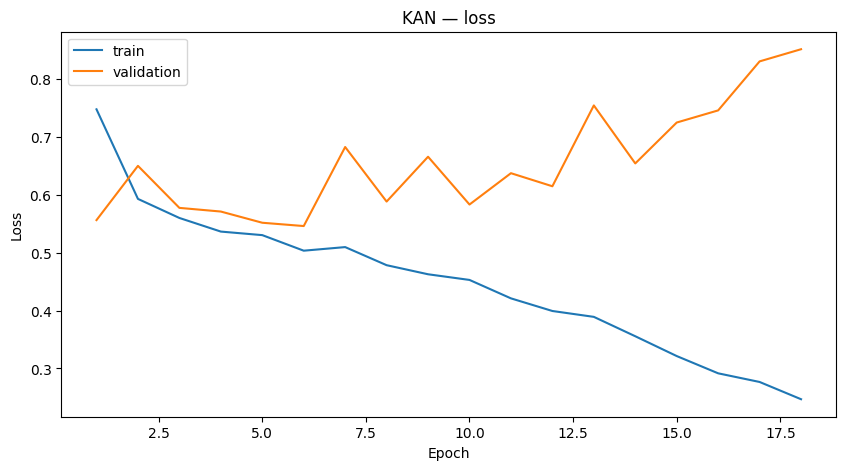

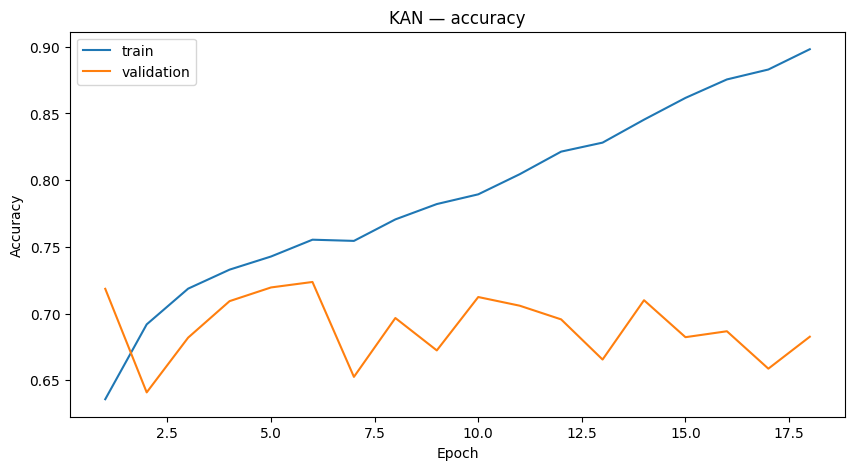

In [16]:
epochs = np.arange(
    1,
    len(history["train_loss"]) + 1,
)

plt.figure(figsize=(10, 5))
plt.plot(
    epochs,
    history["train_loss"],
    label="train",
)
plt.plot(
    epochs,
    history["val_loss"],
    label="validation",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("KAN — loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    epochs,
    history["train_accuracy"],
    label="train",
)
plt.plot(
    epochs,
    history["val_accuracy"],
    label="validation",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("KAN — accuracy")
plt.legend()
plt.show()


## 15. Predykcja na zbiorze testowym


In [17]:
@torch.no_grad()
def predict(
    model,
    loader,
    device,
):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        logits = model(X_batch)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = probabilities.argmax(
            dim=1
        )

        y_true.extend(
            y_batch.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

        y_prob.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

    return (
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_prob),
    )


y_true, y_pred, y_prob = predict(
    model,
    test_loader,
    DEVICE,
)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
    )
)

if len(np.unique(y_true)) == 2:
    auc = roc_auc_score(
        y_true,
        y_prob,
    )

    print(
        f"ROC-AUC: {auc:.4f}"
    )


              precision    recall  f1-score   support

           0     0.7367    0.6822    0.7084      1485
           1     0.6955    0.7486    0.7211      1440

    accuracy                         0.7149      2925
   macro avg     0.7161    0.7154    0.7147      2925
weighted avg     0.7164    0.7149    0.7146      2925

ROC-AUC: 0.7847


## 16. Confusion Matrix


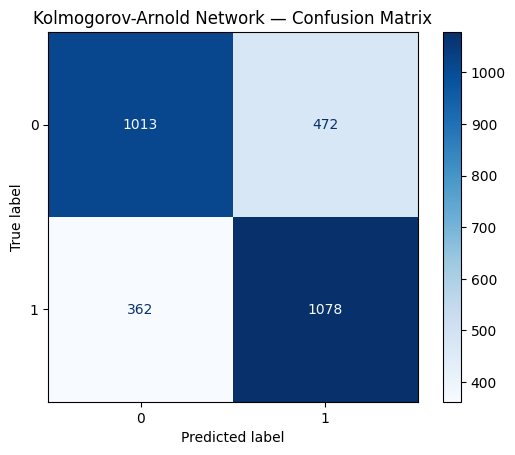

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["0", "1"],
    cmap="Blues",
)

plt.title(
    "Kolmogorov-Arnold Network — Confusion Matrix"
)

plt.show()


## 17. Backtest — model, Momentum i Random


MODEL: KAN
Observations: 2925
Bets: 921 | Bet Frequency: 0.3149
Bet Accuracy: 0.5331
UP Accuracy: 0.5151 | DOWN Accuracy: 0.5575
Confirmed Accuracy: 0.5420 (131 bets)
Neutral Accuracy: 0.5316 (790 bets)
Final Cash: 1610.00 USDT
Total Return: 61.00%
Annualized Sharpe: 3.5780
Bankrupt: False


,Strategy,Number of Bets,Bet Frequency,Bet Accuracy,Final Cash,Total Return (%),Sharpe Ratio,Bankrupt
0,KAN,921,0.3149,0.5331,1610.0,61.0,3.5780,False
1,Momentum,2156,0.7371,0.4768,0.0,-100.0,-2.4619,True
2,Random,921,0.3149,0.4919,850.0,-15.0,-0.4959,False



First executed model bets:


,previous_return,prediction,future_return,signal_type,decision,pnl_usd,cash
2025-11-30 00:00:00+00:00,0.000544,1,0.001007,NEUTRAL,UP,10.0,1010.0
2025-11-30 02:00:00+00:00,0.000213,0,-0.001297,NEUTRAL,DOWN,10.0,1020.0
2025-11-30 03:00:00+00:00,-0.001297,0,0.001253,CONFIRMED,DOWN,-10.0,1010.0
2025-11-30 04:00:00+00:00,0.001253,1,-0.000565,CONFIRMED,UP,-10.0,1000.0
2025-11-30 05:00:00+00:00,-0.000565,1,-0.000818,NEUTRAL,UP,-10.0,990.0
2025-11-30 06:00:00+00:00,-0.000818,1,0.001265,NEUTRAL,UP,10.0,1000.0
2025-11-30 08:00:00+00:00,0.000764,1,0.002375,NEUTRAL,UP,10.0,1010.0
2025-11-30 12:00:00+00:00,-0.002036,0,0.004610,CONFIRMED,DOWN,-10.0,1000.0
2025-11-30 16:00:00+00:00,-0.000707,1,0.004255,NEUTRAL,UP,10.0,1010.0
2025-11-30 19:00:00+00:00,-0.000309,0,0.000010,NEUTRAL,DOWN,-10.0,1000.0


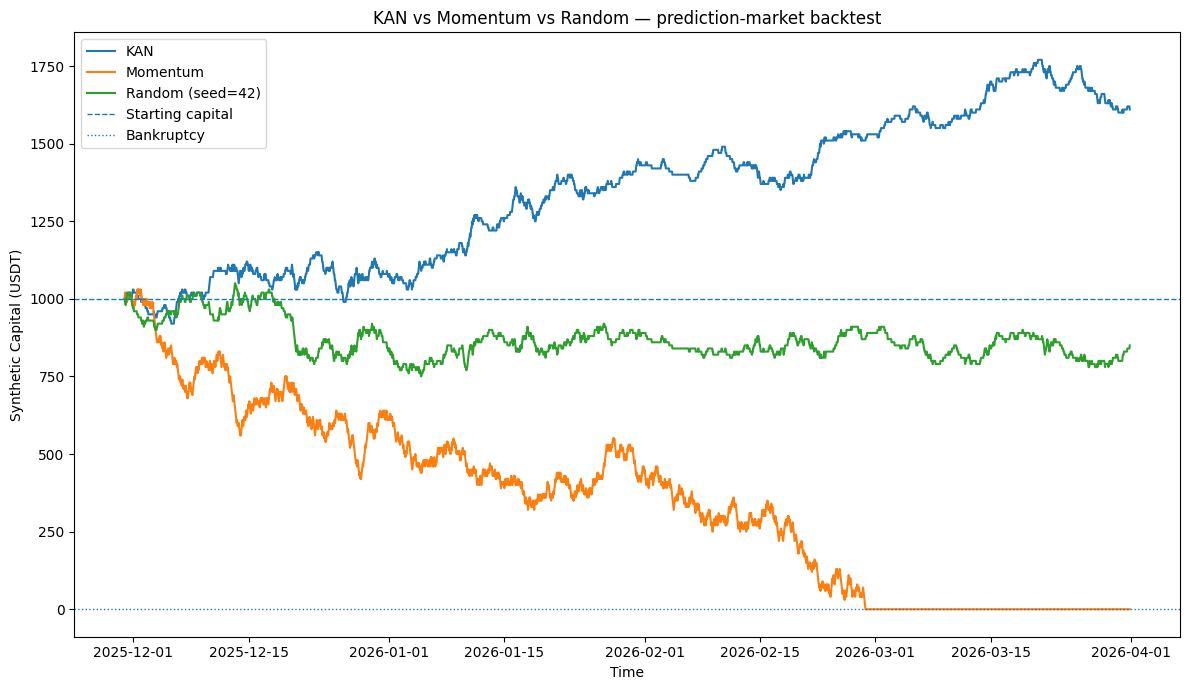

In [19]:
# ============================================================
# FINAL BACKTESTING - PREDICTION MARKET
# KAN + MOMENTUM + RANDOM BENCHMARK
# ============================================================

EPSILON = 0.001
START_CASH = 1000.0
BET_PAYOUT = 10.0
RISK_FREE_ANNUAL = 0.0
RANDOM_SEED = 42

# ------------------------------------------------------------
# 1. ALIGN PREDICTIONS WITH r_t AND r_(t+1)
# ------------------------------------------------------------
# make_windows() creates the first test target at index LAGS_NUM.
# Therefore, for every prediction of y_(t+1):
#   previous_return = r_t     -> raw log return at i-1
#   future_return   = r_(t+1) -> raw log return at i
# We use RAW log returns here (not scaled features), consistently
# with the definition of bin_return_d2d_close.

predictions = np.asarray(y_pred).ravel().astype(int)
if len(predictions) == 0 or not np.isin(predictions, [0, 1]).all():
    raise ValueError("Predictions must be a non-empty binary array containing only 0 and 1.")

test_log_returns_raw = (
    data["log_return_close"]
    .iloc[val_end:]
    .to_numpy(dtype=float)
)

previous_returns = test_log_returns_raw[LAGS_NUM - 1:-1]
future_returns = test_log_returns_raw[LAGS_NUM:]
backtest_index = pd.DatetimeIndex(test_timestamps)

if not (len(predictions) == len(previous_returns) == len(future_returns) == len(backtest_index)):
    raise ValueError(
        "Alignment error: "
        f"predictions={len(predictions)}, previous={len(previous_returns)}, "
        f"future={len(future_returns)}, timestamps={len(backtest_index)}"
    )
if not (np.isfinite(previous_returns).all() and np.isfinite(future_returns).all()):
    raise ValueError("Backtest returns contain non-finite values.")

# Optional consistency check: target reconstructed from raw returns
# must be identical to y_test used for model evaluation.
reconstructed_target = (future_returns > previous_returns).astype(int)
if not np.array_equal(reconstructed_target, np.asarray(y_test).ravel().astype(int)):
    raise ValueError("Target alignment check failed: reconstructed d2d target != y_test.")

# ------------------------------------------------------------
# 2. HELPERS
# ------------------------------------------------------------

def annualized_sharpe(equity, periods_per_year=365 * 24, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if len(equity) < 3:
        return np.nan

    prev = equity[:-1]
    curr = equity[1:]
    valid = prev > 0
    if valid.sum() < 2:
        return np.nan

    returns = (curr[valid] - prev[valid]) / prev[valid]
    rf_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess = returns - rf_per_period
    volatility = excess.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    return np.sqrt(periods_per_year) * excess.mean() / volatility

def settle(direction, future_return):
    if direction == "UP":
        return BET_PAYOUT if future_return > 0 else -BET_PAYOUT
    if direction == "DOWN":
        return BET_PAYOUT if future_return < 0 else -BET_PAYOUT
    return 0.0

def apply_pnl(cash, pnl):
    # A loss cannot push capital below zero.
    if pnl < 0:
        pnl = -min(abs(pnl), cash)
    return max(cash + pnl, 0.0), pnl

# ------------------------------------------------------------
# 3. MODEL STRATEGY
# ------------------------------------------------------------

cash = START_CASH
cash_history = [cash]
pnl_history = []
decision_history = []
signal_type_history = []
bankrupt = False

bets = wins = losses = 0
up_bets = down_bets = up_wins = down_wins = 0
confirmed_bets = confirmed_wins = 0
neutral_bets = neutral_wins = 0

for prediction, previous_return, future_return in zip(
    predictions, previous_returns, future_returns
):
    if bankrupt or cash <= 0:
        bankrupt = True
        decision_history.append("BANKRUPT")
        signal_type_history.append("BANKRUPT")
        pnl_history.append(0.0)
        cash_history.append(0.0)
        continue

    decision = "NO BET"
    signal_type = "NO BET"

    if previous_return > EPSILON and prediction == 1:
        decision = "UP"
        signal_type = "CONFIRMED"
    elif previous_return < -EPSILON and prediction == 0:
        decision = "DOWN"
        signal_type = "CONFIRMED"
    elif abs(previous_return) <= EPSILON:
        decision = "UP" if prediction == 1 else "DOWN"
        signal_type = "NEUTRAL"

    pnl = 0.0
    if decision in ("UP", "DOWN"):
        bets += 1
        if decision == "UP":
            up_bets += 1
        else:
            down_bets += 1

        if signal_type == "CONFIRMED":
            confirmed_bets += 1
        else:
            neutral_bets += 1

        pnl = settle(decision, future_return)
        if pnl > 0:
            wins += 1
            if decision == "UP":
                up_wins += 1
            else:
                down_wins += 1
            if signal_type == "CONFIRMED":
                confirmed_wins += 1
            else:
                neutral_wins += 1
        else:
            losses += 1

        cash, pnl = apply_pnl(cash, pnl)
        if cash <= 0:
            bankrupt = True

    decision_history.append(decision)
    signal_type_history.append(signal_type)
    pnl_history.append(pnl)
    cash_history.append(cash)

# ------------------------------------------------------------
# 4. MOMENTUM BENCHMARK
# ------------------------------------------------------------

momentum_cash = START_CASH
momentum_cash_history = [momentum_cash]
momentum_bets = momentum_wins = 0
momentum_bankrupt = False

for previous_return, future_return in zip(previous_returns, future_returns):
    if momentum_bankrupt or momentum_cash <= 0:
        momentum_bankrupt = True
        momentum_cash_history.append(0.0)
        continue

    direction = "UP" if previous_return > 0 else ("DOWN" if previous_return < 0 else "NO BET")
    if direction in ("UP", "DOWN"):
        momentum_bets += 1
        pnl = settle(direction, future_return)
        if pnl > 0:
            momentum_wins += 1
        momentum_cash, _ = apply_pnl(momentum_cash, pnl)
        if momentum_cash <= 0:
            momentum_bankrupt = True

    momentum_cash_history.append(momentum_cash)

# ------------------------------------------------------------
# 5. RANDOM BENCHMARK
# Same potential entry timestamps as the model; one fixed seed.
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)
random_cash = START_CASH
random_cash_history = [random_cash]
random_bets = random_wins = 0
random_bankrupt = False

for model_decision, future_return in zip(decision_history, future_returns):
    if random_bankrupt or random_cash <= 0:
        random_bankrupt = True
        random_cash_history.append(0.0)
        continue

    if model_decision in ("UP", "DOWN"):
        direction = "UP" if rng.integers(0, 2) == 1 else "DOWN"
        random_bets += 1
        pnl = settle(direction, future_return)
        if pnl > 0:
            random_wins += 1
        random_cash, _ = apply_pnl(random_cash, pnl)
        if random_cash <= 0:
            random_bankrupt = True

    random_cash_history.append(random_cash)

# ------------------------------------------------------------
# 6. METRICS
# ------------------------------------------------------------

n_obs = len(predictions)
model_accuracy = wins / bets if bets else np.nan
model_bet_frequency = bets / n_obs if n_obs else np.nan
up_accuracy = up_wins / up_bets if up_bets else np.nan
down_accuracy = down_wins / down_bets if down_bets else np.nan
confirmed_accuracy = confirmed_wins / confirmed_bets if confirmed_bets else np.nan
neutral_accuracy = neutral_wins / neutral_bets if neutral_bets else np.nan

model_sharpe = annualized_sharpe(cash_history, risk_free_annual=RISK_FREE_ANNUAL)
momentum_sharpe = annualized_sharpe(momentum_cash_history, risk_free_annual=RISK_FREE_ANNUAL)
random_sharpe = annualized_sharpe(random_cash_history, risk_free_annual=RISK_FREE_ANNUAL)

comparison = pd.DataFrame({
    "Strategy": ["KAN", "Momentum", "Random"],
    "Number of Bets": [bets, momentum_bets, random_bets],
    "Bet Frequency": [
        model_bet_frequency,
        momentum_bets / n_obs if n_obs else np.nan,
        random_bets / n_obs if n_obs else np.nan,
    ],
    "Bet Accuracy": [
        model_accuracy,
        momentum_wins / momentum_bets if momentum_bets else np.nan,
        random_wins / random_bets if random_bets else np.nan,
    ],
    "Final Cash": [cash, momentum_cash, random_cash],
    "Total Return (%)": [
        (cash / START_CASH - 1) * 100,
        (momentum_cash / START_CASH - 1) * 100,
        (random_cash / START_CASH - 1) * 100,
    ],
    "Sharpe Ratio": [model_sharpe, momentum_sharpe, random_sharpe],
    "Bankrupt": [bankrupt, momentum_bankrupt, random_bankrupt],
})

print(f"MODEL: KAN")
print(f"Observations: {n_obs}")
print(f"Bets: {bets} | Bet Frequency: {model_bet_frequency:.4f}")
print(f"Bet Accuracy: {model_accuracy:.4f}")
print(f"UP Accuracy: {up_accuracy:.4f} | DOWN Accuracy: {down_accuracy:.4f}")
print(f"Confirmed Accuracy: {confirmed_accuracy:.4f} ({confirmed_bets} bets)")
print(f"Neutral Accuracy: {neutral_accuracy:.4f} ({neutral_bets} bets)")
print(f"Final Cash: {cash:.2f} USDT")
print(f"Total Return: {(cash / START_CASH - 1) * 100:.2f}%")
print(f"Annualized Sharpe: {model_sharpe:.4f}")
print(f"Bankrupt: {bankrupt}")

display(comparison.round({
    "Bet Frequency": 4,
    "Bet Accuracy": 4,
    "Final Cash": 2,
    "Total Return (%)": 2,
    "Sharpe Ratio": 4,
}))

# Detailed model decisions
backtest_results = pd.DataFrame({
    "previous_return": previous_returns,
    "prediction": predictions,
    "future_return": future_returns,
    "signal_type": signal_type_history,
    "decision": decision_history,
    "pnl_usd": pnl_history,
    "cash": cash_history[1:],
}, index=backtest_index)

print("\nFirst executed model bets:")
display(backtest_results[backtest_results["decision"].isin(["UP", "DOWN"])].head(10))

# ------------------------------------------------------------
# 7. EQUITY CURVES
# ------------------------------------------------------------
curve_index = pd.DatetimeIndex([backtest_index[0] - pd.Timedelta(hours=1)]).append(backtest_index)

plt.figure(figsize=(12, 7))
plt.plot(curve_index, cash_history, label="KAN")
plt.plot(curve_index, momentum_cash_history, label="Momentum")
plt.plot(curve_index, random_cash_history, label="Random (seed=42)")
plt.axhline(START_CASH, linestyle="--", linewidth=1, label="Starting capital")
plt.axhline(0, linestyle=":", linewidth=1, label="Bankruptcy")
plt.xlabel("Time")
plt.ylabel("Synthetic Capital (USDT)")
plt.title("KAN vs Momentum vs Random — prediction-market backtest")
plt.legend()
plt.tight_layout()
plt.show()



## 18. Zapis modelu


In [20]:
CHECKPOINT_PATH = "/content/kan_btc_classifier.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "lags_num": LAGS_NUM,
        "hidden_dims": KAN_HIDDEN_DIMS,
        "grid_size": GRID_SIZE,
        "grid_range": GRID_RANGE,
        "output_value": OUTPUT_VALUE,
        "scaler_enabled": SCALER_BOOLEAN,
        "scaler_mean": (
            scaler.mean_.tolist()
            if scaler is not None
            else None
        ),
        "scaler_scale": (
            scaler.scale_.tolist()
            if scaler is not None
            else None
        ),
    },
    CHECKPOINT_PATH,
)

print(
    "Zapisano:",
    CHECKPOINT_PATH,
)


Zapisano: /content/kan_btc_classifier.pt


## 19. Parametry do eksperymentów

Dla uczciwego porównania z MOMENT-1 pozostaw bez zmian:
- ten sam CSV,
- target,
- `LAGS_NUM=240`,
- granice train/validation/test,
- metryki i backtest.

Najważniejsze hiperparametry KAN do testowania:
- `KAN_HIDDEN_DIMS`: np. `[32]`, `[64, 16]`, `[128, 32]`,
- `GRID_SIZE`: np. `5`, `8`, `12`,
- `LEARNING_RATE`: np. `3e-4`, `1e-3`,
- `WEIGHT_DECAY`.

KAN ma znacznie więcej parametrów na pojedyncze połączenie niż zwykła warstwa liniowa, dlatego zbyt szerokie warstwy szybko zwiększają zużycie pamięci.
